# Data Cleaning Perfect - Bureaux Vente Marrakech
This notebook implements the 'Perfect Cleaning' pipeline for Machine Learning preparation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# File path
file_path = '../../data/marrakech_immo_vente/bureaux_vente.csv'

# Load data
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {file_path}")
    print(f"Initial shape: {df.shape}")
    display(df.head())
else:
    print(f"ERROR: File not found at {file_path}")

Successfully loaded ../../data/marrakech_immo_vente/bureaux_vente.csv
Initial shape: (241, 34)


,id,titre,prix,localisation,type_bien,surface,chambres,salles_bain,description,agence,...,etage,surface_terrain,prix_num,surface_num,chambres_num,salles_bain_num,nb_pieces,quartier,prix_m2,prix_m2_median_quartier
0,8314581.0,Centre de Pilates à vendre Sur Guéliz Marrakech,1 100 000 DH,"Guéliz, Marrakech",Maison,NaN,NaN,1 Salle de bain,NaN,Particulier,...,-1,NaN,1100000.0,NaN,0.0,1.0,2.0,Guéliz,NaN,17391.304348
1,8300040.0,Bureau en vente à Guéliz. Surface totale 51 m²...,860 000 DH,"Guéliz, Marrakech",Maison,51 m²,NaN,1 Salle de bain,NaN,Particulier,...,-1,NaN,860000.0,51.0,0.0,1.0,2.0,Guéliz,16862.745098,17391.304348
2,8303988.0,"Plateau de bureau à Guéliz, Allal El Fassi",850 000 DH,"Boukar, Marrakech",Maison,63 m²,NaN,1 Salle de bain,NaN,Particulier,...,-1,NaN,850000.0,63.0,0.0,1.0,2.0,Autre,13492.063492,13492.063492
3,8276978.0,Plateau Bureau de 75 m2 à Targa,1 275 000 DH,"Hay Targa, Marrakech",Maison,75 m²,NaN,1 Salle de bain,NaN,Particulier,...,-1,NaN,1275000.0,75.0,0.0,1.0,2.0,Targa,17000.000000,15740.740741
4,8270525.0,Bureau très bien placé à vendre,1 090 800 DH,"Guéliz, Marrakech",Maison,61 m²,NaN,1 Salle de bain,NaN,Particulier,...,-1,NaN,1090800.0,61.0,0.0,1.0,2.0,Guéliz,17881.967213,17391.304348


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       81 non-null     str    
 1   titre                    241 non-null    str    
 2   prix                     241 non-null    str    
 3   localisation             241 non-null    str    
 4   type_bien                241 non-null    str    
 5   surface                  175 non-null    str    
 6   chambres                 11 non-null     str    
 7   salles_bain              165 non-null    str    
 8   description              170 non-null    str    
 9   agence                   81 non-null     str    
 10  url                      241 non-null    str    
 11  source                   241 non-null    str    
 12  piscine                  241 non-null    int64  
 13  parking                  241 non-null    int64  
 14  ascenseur                241 non-null

## 1. Target Protection & Deduplication
We must drop rows without a price (target) and remove duplicates.

In [3]:
df.describe()

,piscine,parking,ascenseur,terrasse,jardin,climatisation,securite,vue,meuble,neuf,...,hammam,etage,surface_terrain,prix_num,surface_num,chambres_num,salles_bain_num,nb_pieces,prix_m2,prix_m2_median_quartier
count,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,...,241.000000,241.000000,0.0,1.980000e+02,175.000000,241.000000,241.000000,241.000000,1.550000e+02,232.000000
mean,0.008299,0.132780,0.149378,0.008299,0.016598,0.049793,0.024896,0.020747,0.037344,0.174274,...,0.004149,-0.759336,NaN,6.364962e+06,112.188571,0.128631,0.780083,1.925311,8.928465e+04,15273.365681
std,0.090908,0.340043,0.357202,0.090908,0.128024,0.217969,0.156133,0.142832,0.189999,0.380134,...,0.064416,0.836763,NaN,7.104581e+07,263.728905,0.698249,0.794104,1.249426,9.115293e+05,1843.954714
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.000000,NaN,1.500000e+02,0.000000,0.000000,0.000000,1.000000,1.875000e+01,13492.063492
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.000000,NaN,3.625000e+05,50.000000,0.000000,0.000000,1.000000,1.285714e+04,13580.246914
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.000000,NaN,9.275000e+05,65.000000,0.000000,1.000000,2.000000,1.590164e+04,13658.008658
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.000000,NaN,1.340000e+06,87.500000,0.000000,1.000000,2.000000,1.844283e+04,17164.179104
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,NaN,1.000000e+09,2400.000000,7.000000,6.000000,14.000000,1.136364e+07,19642.857143


In [4]:
# Conversion des prix en DH si nécessaire
if 'df' in locals():
    if 'prix' in df.columns and 'prix_num' in df.columns:
        # Taux de conversion approximatif (1 EUR = 10.8 MAD)
        EUR_TO_MAD = 10.8
        
        def convert_to_dh(row):
            price_str = str(row['prix']).lower() if pd.notna(row['prix']) else ''
            price_num = row['prix_num']
            
            # Si le prix contient l'euro et qu'on n'a pas encore une valeur en DH cohérente
            if '€' in price_str or 'eur' in price_str:
                import re
                # Extraire le montant en euro (souvent le premier nombre)
                nums = re.findall(r'\d+', price_str.replace(' ', '').replace(',', ''))
                if nums:
                    # Si c'est en euros, on multiplie par notre taux
                    euro_val = float(nums[0])
                    # On vérifie si price_num est déjà une conversion correcte (proche de euro_val * 10)
                    # Sinon on force la conversion
                    if pd.isna(price_num) or price_num < euro_val * 5:
                        return round(euro_val * EUR_TO_MAD)
            
            return price_num
            
        df['prix_num'] = df.apply(convert_to_dh, axis=1)
        print("Prix uniformisés en DH.")

Prix uniformisés en DH.


In [5]:
df.columns

Index(['id', 'titre', 'prix', 'localisation', 'type_bien', 'surface',
       'chambres', 'salles_bain', 'description', 'agence', 'url', 'source',
       'piscine', 'parking', 'ascenseur', 'terrasse', 'jardin',
       'climatisation', 'securite', 'vue', 'meuble', 'neuf', 'cave', 'hammam',
       'etage', 'surface_terrain', 'prix_num', 'surface_num', 'chambres_num',
       'salles_bain_num', 'nb_pieces', 'quartier', 'prix_m2',
       'prix_m2_median_quartier'],
      dtype='str')

In [6]:
df.shape

(241, 34)

In [7]:
if 'df' in locals():
    # 1. Drop missing target
    if 'prix_num' in df.columns:
        initial_len = len(df)
        df = df.dropna(subset=['prix_num'])
        print(f"Dropped {initial_len - len(df)} rows with missing prix_num")
    
    # 2. Drop duplicates
    initial_len = len(df)
    df = df.drop_duplicates()
    print(f"Dropped {initial_len - len(df)} duplicate rows")

Dropped 43 rows with missing prix_num
Dropped 0 duplicate rows


## 2. Feature Selection & Data Leakage Prevention
Drop non-predictive columns and columns that cause data leakage (like prix_m2).

In [8]:
if 'df' in locals():
    cols_to_drop = ['id', 'url', 'source', 'titre', 'description', 'agence', 'prix', 'surface', 'localisation', 'chambres', 'salles_bain', 'surface_terrain']
    existing_drops = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=existing_drops)
    print(f"Dropped columns: {existing_drops}")
    print(f"Remaining columns: {df.columns.tolist()}")

Dropped columns: ['id', 'url', 'source', 'titre', 'description', 'agence', 'prix', 'surface', 'localisation', 'chambres', 'salles_bain', 'surface_terrain']
Remaining columns: ['type_bien', 'piscine', 'parking', 'ascenseur', 'terrasse', 'jardin', 'climatisation', 'securite', 'vue', 'meuble', 'neuf', 'cave', 'hammam', 'etage', 'prix_num', 'surface_num', 'chambres_num', 'salles_bain_num', 'nb_pieces', 'quartier', 'prix_m2', 'prix_m2_median_quartier']


## 3. Intelligent Imputation
Handling missing values for features.

In [9]:
if 'df' in locals():
    # Missing values before
    print("Missing values before imputation:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    
    # 1. Numeric: Median
    if 'surface_num' in df.columns:
        df['surface_num'] = df['surface_num'].fillna(df['surface_num'].median())
    
    
    # 2. Rooms/Baths logic - Imputation par la moyenne au lieu de 0.0
for col in ['chambres_num', 'salles_bain_num']:
    if col in df.columns:
        # On remplace les 0 par NaN pour qu'ils soient imputés par la moyenne
        df[col] = df[col].replace(0, np.nan)
        # Remplissage par la moyenne (arrondie à l'entier le plus proche)
        df[col] = df[col].fillna(round(df[col].mean() if not df[col].isnull().all() else 1))

# 1b. Calcul du prix_m2 manquant à partir du prix_num et surface_num
if 'prix_m2' in df.columns and 'prix_num' in df.columns and 'surface_num' in df.columns:
    # On remplace temporairement les surfaces 0 par NaN pour éviter la division par zéro
    temp_surface = df['surface_num'].replace(0, np.nan)
    df['prix_m2'] = df['prix_m2'].fillna(df['prix_num'] / temp_surface)
    
    # 3. Categorical: Mode
    cat_cols = ['agence', 'type_bien', 'quartier']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Inconnu')

    print("\nMissing values after imputation:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before imputation:
surface_num                42
prix_m2                    43
prix_m2_median_quartier     7
dtype: int64

Missing values after imputation:
prix_m2                    1
prix_m2_median_quartier    7
dtype: int64


In [10]:
df.dropna()

,type_bien,piscine,parking,ascenseur,terrasse,jardin,climatisation,securite,vue,meuble,...,hammam,etage,prix_num,surface_num,chambres_num,salles_bain_num,nb_pieces,quartier,prix_m2,prix_m2_median_quartier
0,Maison,0,0,0,0,0,0,0,0,0,...,0,-1,1100000.0,65.5,3.0,1.0,2.0,Guéliz,16793.893130,17391.304348
1,Maison,0,1,0,0,0,0,0,0,0,...,0,-1,860000.0,51.0,3.0,1.0,2.0,Guéliz,16862.745098,17391.304348
2,Maison,0,0,0,0,0,0,0,0,0,...,0,-1,850000.0,63.0,3.0,1.0,2.0,Autre,13492.063492,13492.063492
3,Maison,0,0,0,0,0,0,0,0,0,...,0,-1,1275000.0,75.0,3.0,1.0,2.0,Targa,17000.000000,15740.740741
4,Maison,0,0,0,0,0,0,0,0,0,...,0,-1,1090800.0,61.0,3.0,1.0,2.0,Guéliz,17881.967213,17391.304348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,Bureaux,0,0,0,0,0,0,0,0,0,...,0,-1,4100000.0,223.0,3.0,3.0,4.0,Guéliz,18385.650224,17164.179104
237,Bureaux,0,0,0,0,0,0,0,0,0,...,0,-1,2800000.0,345.0,3.0,4.0,5.0,Autre,8115.942029,13580.246914
238,Bureaux,0,0,0,0,0,0,0,0,0,...,0,-1,400000.0,20.0,3.0,1.0,2.0,Guéliz,20000.000000,17164.179104
239,Bureaux,0,0,0,0,0,0,0,0,0,...,0,-1,880000.0,66.0,3.0,1.0,2.0,Guéliz,13333.333333,17164.179104


In [11]:
df.isnull().sum()

type_bien                  0
piscine                    0
parking                    0
ascenseur                  0
terrasse                   0
jardin                     0
climatisation              0
securite                   0
vue                        0
meuble                     0
neuf                       0
cave                       0
hammam                     0
etage                      0
prix_num                   0
surface_num                0
chambres_num               0
salles_bain_num            0
nb_pieces                  0
quartier                   0
prix_m2                    1
prix_m2_median_quartier    7
dtype: int64

In [12]:
df.shape

(198, 22)

## 4. Feature Engineering
Applying log transformations to stabilize variance.

In [13]:
if 'df' in locals():
    if 'prix_num' in df.columns:
        df['log_prix_num'] = np.log1p(df['prix_num'])
        print("Created log_prix_num")
    
    if 'surface_num' in df.columns:
        df['log_surface_num'] = np.log1p(df['surface_num'])
        print("Created log_surface_num")

Created log_prix_num
Created log_surface_num


## 5. Outlier Detection & Removal
Using 1st and 99th percentiles.

In [14]:
if 'df' in locals():
    for col in ['prix_num', 'surface_num']:
        if col in df.columns:
            q_low = df[col].quantile(0.01)
            q_hi  = df[col].quantile(0.99)
            df = df[(df[col] <= q_hi) & (df[col] >= q_low)]
            print(f"Filtered {col} between {q_low:.2f} and {q_hi:.2f}")
    
    print(f"Final shape: {df.shape}")

Filtered prix_num between 500.00 and 34600000.00
Filtered surface_num between 9.52 and 1500.08
Final shape: (191, 24)


## 6. Exporting ML-Ready Data

In [15]:
if 'df' in locals():
    output_dir = '../../data/cleaned_data/vente'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    output_path = os.path.join(output_dir, 'bureaux_vente_cleaned.csv')
    df.to_csv(output_path, index=False)
    print(f"Success! ML-ready data saved to {output_path}")

Success! ML-ready data saved to ../../data/cleaned_data/vente/bureaux_vente_cleaned.csv


## 7. Model Training
Training the predictive model using the pipeline.


════════════════════════════════════════════════════════════
  PIPELINE BUREAUX VENTE
════════════════════════════════════════════════════════════
 Chargement : 241 lignes, 34 colonnes
   Total initial : 241


/home/nouhayla/Desktop/stage/gateone-deploy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Après filtres : 138 lignes
   Prix médian    : 1,100,000 MAD
   Surface médiane: 67 m²
   pm² médian     : 16,277 MAD/m²

 Split train/test...
 Optuna 50 trials sur X_train (CV 5-fold)...


  0%|                                                    | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.658697:   0%|               | 0/50 [00:02<?, ?it/s]

...

Best trial: 5. Best value: 0.686743:  98%|█████▉| 49/50 [00:15<00:00,  5.26it/s]

Best trial: 5. Best value: 0.686743: 100%|██████| 50/50 [00:15<00:00,  5.56it/s]

Best trial: 5. Best value: 0.686743: 100%|██████| 50/50 [00:15<00:00,  3.29it/s]

 Meilleur R² CV : 0.6867
   n_estimators                  : 551
   max_depth                     : 8
   learning_rate                 : 0.01186828459896995
   max_leaves                    : 37
   subsample                     : 0.8969534274543511
   colsample_bytree              : 0.9192501412989045
   colsample_bylevel             : 0.5231507248311753
   min_child_weight              : 7
   reg_alpha                     : 0.0007389774945443005
   reg_lambda                    : 0.001802647040687821
   gamma                         : 1.0856381345992823e-05
 Entraînement...



═════════════════════════════════════════════
  MÉTRIQUES — BUREAUX VENTE
═════════════════════════════════════════════
  MAE              :         900,083 MAD
  RMSE             :       3,151,782 MAD
  R²               :          0.6373
  MAPE             :           26.02 %
  CV R² (5 folds)  : 0.6837 ± 0.1251
═════════════════════════════════════════════


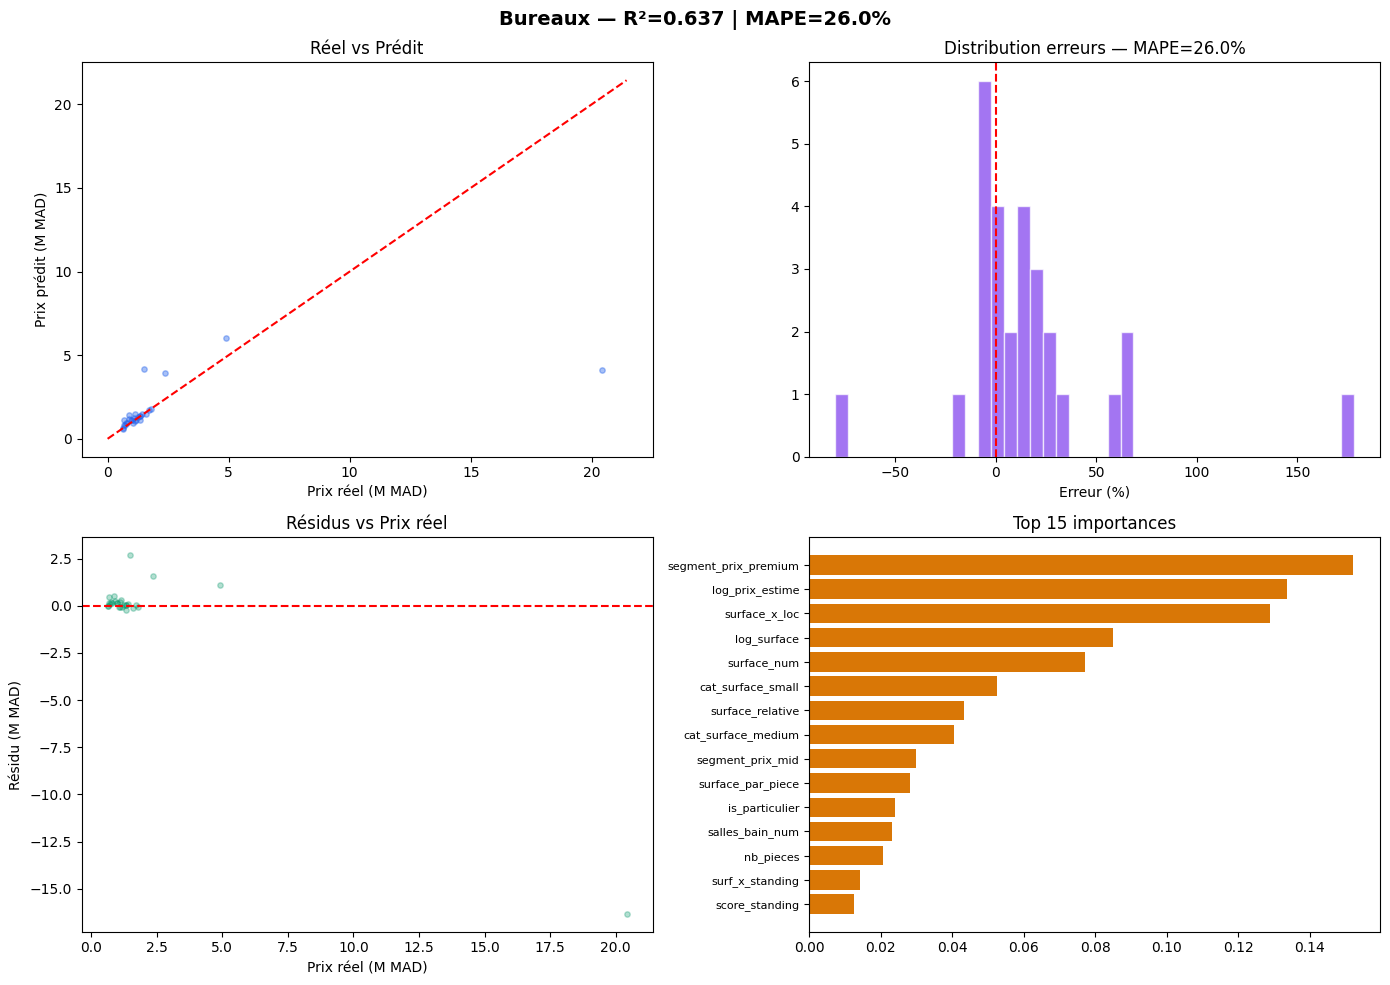


 Modèle sauvegardé : /home/nouhayla/Desktop/stage/gateone-deploy/model_training/models/xgb_bureaux_vente.pkl


In [16]:
import sys
sys.path.append('../../pipeline/ventes')
import pip_bureaux

# Run the pipeline training
pipeline_final, stats, metrics, study = pip_bureaux.run_pipeline(tune=True, n_trials=50)
